<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Yıl                                  23 non-null     int64  
 1   Sigara İçen Kişi Sayısı (milyon)     23 non-null     float64
 2   Sigaradan Ölen Kişi Sayısı (milyon)  23 non-null     float64
 3   Toplam Ölen Kişi Sayısı (milyon)     23 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 868.0 bytes
None
    Yıl  Sigara İçen Kişi Sayısı (milyon)  \
0  2000                             1.638   
1  2001                             1.643   
2  2002                             1.648   
3  2003                             1.653   
4  2004                             1.658   

   Sigaradan Ölen Kişi Sayısı (milyon)  Toplam Ölen Kişi Sayısı (milyon)  
0                                  4.9                              54.8  
1                    

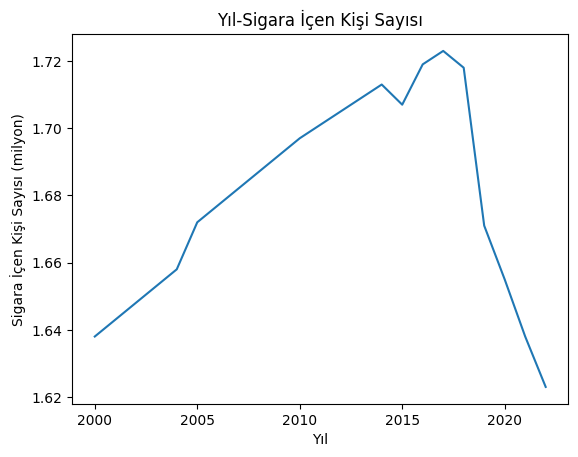

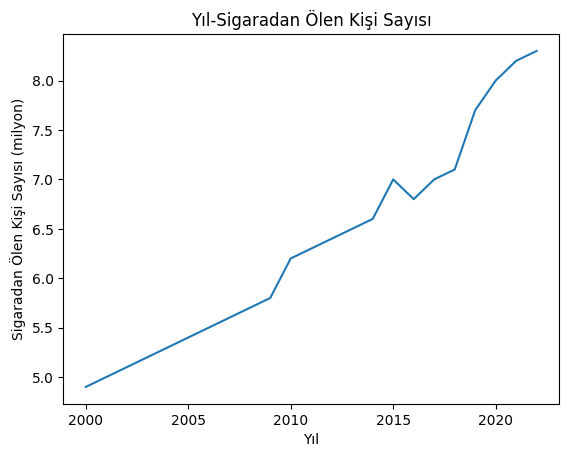

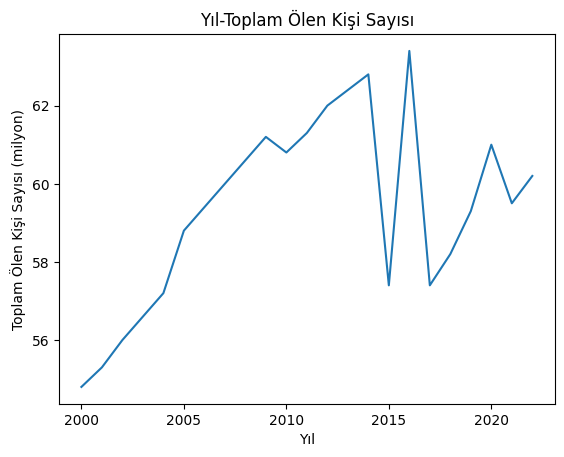

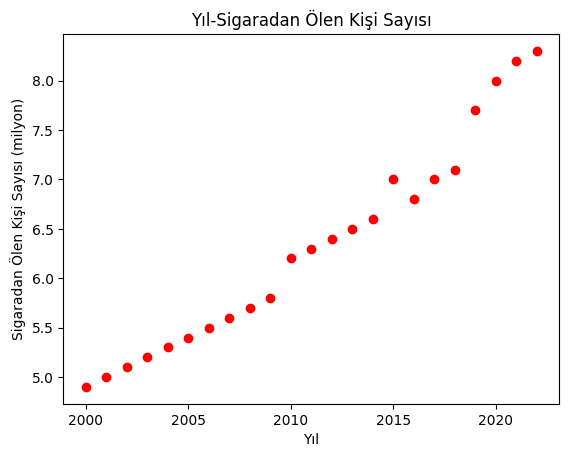

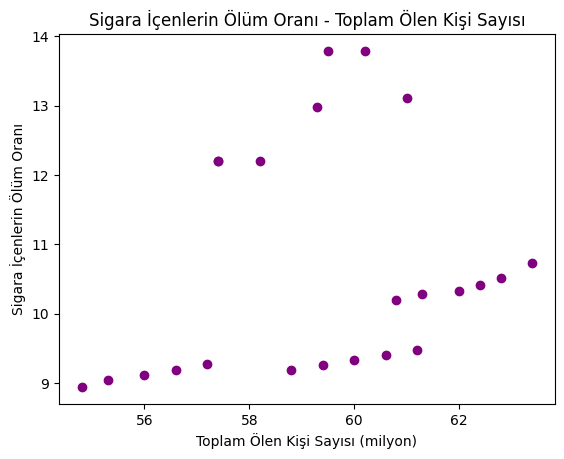

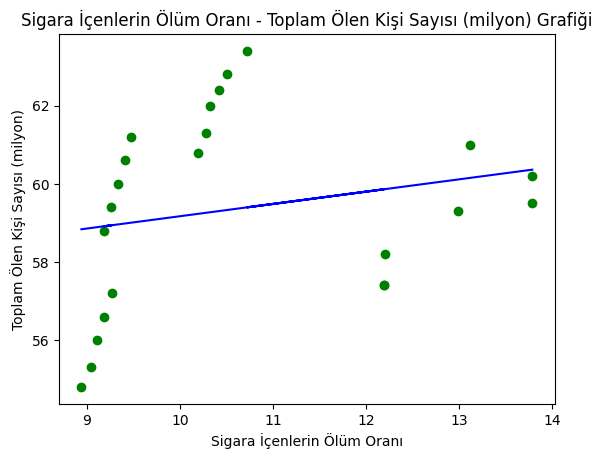

Mean Squared Error: 5.358364420655435
R^2 Score: 0.045700537811843245


In [1]:
# Gerekli kütüphaneleri import edelim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Veriyi yükleyelim
sigara_verisi = pd.read_csv("sigara_olumOranı_dataset.csv")

# Veriyi kontrol edelim
print(sigara_verisi.info())
print(sigara_verisi.head())

# Eksik verileri kontrol edelim
print(sigara_verisi.isnull().sum())

# Sigara İçen Kişi Sayısı (milyon) - Yıl bazında grafiği
plt.plot(sigara_verisi["Yıl"], sigara_verisi["Sigara İçen Kişi Sayısı (milyon)"])
plt.xlabel('Yıl')
plt.ylabel('Sigara İçen Kişi Sayısı (milyon)')
plt.title('Yıl-Sigara İçen Kişi Sayısı')
plt.show()

# Sigaradan Ölen Kişi Sayısı (milyon) - Yıl bazında grafiği
plt.plot(sigara_verisi["Yıl"], sigara_verisi["Sigaradan Ölen Kişi Sayısı (milyon)"])
plt.xlabel('Yıl')
plt.ylabel('Sigaradan Ölen Kişi Sayısı (milyon)')
plt.title('Yıl-Sigaradan Ölen Kişi Sayısı')
plt.show()

# Toplam Ölen Kişi Sayısı (milyon) - Yıl bazında grafiği
plt.plot(sigara_verisi["Yıl"], sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"])
plt.xlabel('Yıl')
plt.ylabel('Toplam Ölen Kişi Sayısı (milyon)')
plt.title('Yıl-Toplam Ölen Kişi Sayısı')
plt.show()

# Yıl-Sigaradan Ölen Kişi Sayısı Scatter Grafiği
plt.scatter(sigara_verisi["Yıl"], sigara_verisi["Sigaradan Ölen Kişi Sayısı (milyon)"], color="red")
plt.xlabel('Yıl')
plt.ylabel('Sigaradan Ölen Kişi Sayısı (milyon)')
plt.title('Yıl-Sigaradan Ölen Kişi Sayısı')
plt.show()

# Yeni bir sütun ekleyelim: Sigara İçenlerin Ölüm Oranı
sigara_verisi["Sigara İçenlerin Ölüm Oranı"] = (sigara_verisi["Sigaradan Ölen Kişi Sayısı (milyon)"] / sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"]) * 100

# Sigara İçenlerin Ölüm Oranı - Toplam Ölen Kişi Sayısı Scatter Grafiği
plt.scatter(sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"], sigara_verisi["Sigara İçenlerin Ölüm Oranı"], color="purple")
plt.xlabel('Toplam Ölen Kişi Sayısı (milyon)')
plt.ylabel('Sigara İçenlerin Ölüm Oranı')
plt.title('Sigara İçenlerin Ölüm Oranı - Toplam Ölen Kişi Sayısı')
plt.show()

# Modelleme için veriyi hazırlayalım
# Sigara İçenlerin Ölüm Oranı sayısal formata geçirelim (yüzdeyi çıkarttık)
# Sigara İçenlerin Ölüm Oranı zaten sayısal formatta olduğundan, burada bir değişiklik yapılmadı.
# Ama modelin doğru çalışabilmesi için bu sütun sayısal olmalı.

# Linear Regression Modeli
model = LinearRegression()

# Modeli eğitelim
model.fit(sigara_verisi[["Sigara İçenlerin Ölüm Oranı"]], sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"])

# Tahmin edilen değerleri alalım
tahmin_edilen_degerler = model.predict(sigara_verisi[["Sigara İçenlerin Ölüm Oranı"]])

# Modeli görselleştirelim
plt.scatter(sigara_verisi["Sigara İçenlerin Ölüm Oranı"], sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"], color="green")
plt.plot(sigara_verisi["Sigara İçenlerin Ölüm Oranı"], tahmin_edilen_degerler, color="blue")
plt.xlabel("Sigara İçenlerin Ölüm Oranı")
plt.ylabel("Toplam Ölen Kişi Sayısı (milyon)")
plt.title("Sigara İçenlerin Ölüm Oranı - Toplam Ölen Kişi Sayısı (milyon) Grafiği")
plt.show()

# Model değerlendirmesi
mse = mean_squared_error(sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"], tahmin_edilen_degerler)
r2 = r2_score(sigara_verisi["Toplam Ölen Kişi Sayısı (milyon)"], tahmin_edilen_degerler)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
